# EDA Comparativo y Verificación de Calidad del Preprocesamiento de EmoEvent

Este notebook verifica la calidad del pipeline de preprocesamiento aplicado al dataset EmoEvent:
- Normalización de texto (eliminación de HASHTAG/USER/URL, conversión de emojis)
- Traducción ES --> EN de clases minoritarias (fear, disgust, surprise)
- Generación de datos sintéticos para balanceo de clases
- Splits train/val/test sin data leakage

## 0. Imports y configuración

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from pathlib import Path

def save_custom_plot(filename, dpi=300):
    """
    Guarda la figura activa de matplotlib en el directorio de resultados.
    Asegura alta resolución y recorta los márgenes blancos innecesarios.
    """
    output_dir = Path('../data/figures')
    
    # Aseguramos que la extensión .png esté presente
    if not filename.endswith('.png'):
        filename += '.png'
        
    plt.savefig(output_dir / filename, bbox_inches='tight', dpi=dpi)
    print(f"Gráfica guardada: {filename}")

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

DATA_ROOT = Path('../data')
RAW_ES   = DATA_ROOT / 'raw/emoevent/emoevent_es.csv'
RAW_EN   = DATA_ROOT / 'raw/emoevent/emoevent_en.csv'
PREP_CSV = DATA_ROOT / 'processed/emoevent_preprocessed.csv'
SYNT_CSV = DATA_ROOT / 'processed/emoevent_preprocessed_synthetic.csv'
NS_DIR   = DATA_ROOT / 'processed/no_synthetic'
WS_DIR   = DATA_ROOT / 'processed/with_synthetic'

# Paleta de emociones
EMOTION_ORDER = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'others']
PALETTE = sns.color_palette('tab10', n_colors=len(EMOTION_ORDER))
EMO_PALETTE = dict(zip(EMOTION_ORDER, PALETTE))

## 1. Carga de los datasets

In [10]:
# Carga de datos
raw_es   = pd.read_csv(RAW_ES, sep='\t')
raw_en   = pd.read_csv(RAW_EN, sep='\t')
prep     = pd.read_csv(PREP_CSV)
synt_full = pd.read_csv(SYNT_CSV)

ns_train = pd.read_csv(NS_DIR / 'emoevent_train.csv')
ns_val   = pd.read_csv(NS_DIR / 'emoevent_val.csv')
ns_test  = pd.read_csv(NS_DIR / 'emoevent_test.csv')

ws_train = pd.read_csv(WS_DIR / 'emoevent_train.csv')
ws_val   = pd.read_csv(WS_DIR / 'emoevent_val.csv')
ws_test  = pd.read_csv(WS_DIR / 'emoevent_test.csv')

print(f'raw_es: {raw_es.shape}')
print(f'raw_en: {raw_en.shape}')
print(f'prep: {prep.shape}')
print(f'synt_full: {synt_full.shape}')
print(f'ns  train/val/test: {ns_train.shape} / {ns_val.shape} / {ns_test.shape}')
print(f'ws  train/val/test: {ws_train.shape} / {ws_val.shape} / {ws_test.shape}')

raw_es: (8409, 4)
raw_en: (7303, 4)
prep: (7231, 5)
synt_full: (7311, 5)
ns  train/val/test: (5061, 5) / (1085, 5) / (1085, 5)
ws  train/val/test: (5141, 5) / (1085, 5) / (1085, 5)


## 2. Comparativa de Distribución de Clases

In [7]:
# Función para generar métricas de desequilibrio
def imbalance_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    counts = df['emotion'].value_counts().reindex(EMOTION_ORDER, fill_value=0)
    total = counts.sum()
    pct = (counts / total * 100).round(2)
    
    # Evitar división por cero sustituyendo 0 por NaN para el cálculo del ratio
    min_count = counts.replace(0, np.nan)
    ratio = (counts.max() / min_count).round(2)
    
    return pd.DataFrame({'emoción': EMOTION_ORDER,
                         f'n_{label}': counts.values,
                         f'%_{label}': pct.values,
                         f'ratio_{label}': ratio.values}).set_index('emoción')

# Generación de la tabla comparativa
tbl_ns = imbalance_table(ns_train, 'sin_sint')
tbl_ws = imbalance_table(ws_train, 'con_sint')
tbl_comp = pd.concat([tbl_ns, tbl_ws], axis=1)

print('Tabla Comparativa en Train (Sin vs Con Sintéticos)')
display(tbl_comp.style
        .format({
            '%_sin_sint': '{:.2f}%', '%_con_sint': '{:.2f}%', 
            'ratio_sin_sint': '{:.2f}x', 'ratio_con_sint': '{:.2f}x'
        }, na_rep='-')
        .background_gradient(cmap='Blues', subset=[c for c in tbl_comp.columns if c.startswith('n_')])
        .set_caption('Distribución de clases en el conjunto de entrenamiento (Train)'))

Tabla Comparativa en Train (Sin vs Con Sintéticos)


,n_sin_sint,%_sin_sint,ratio_sin_sint,n_con_sint,%_con_sint,ratio_con_sint
emoción,,,,,,
anger,599,11.84%,2.12x,599,11.65%,2.12x
disgust,648,12.80%,1.96x,688,13.38%,1.85x
fear,173,3.42%,7.34x,213,4.14%,5.96x
joy,1270,25.09%,1.00x,1270,24.70%,1.00x
sadness,706,13.95%,1.80x,706,13.73%,1.80x
surprise,405,8.00%,3.14x,405,7.88%,3.14x
others,1260,24.90%,1.01x,1260,24.51%,1.01x


Gráfica guardada: train_class_comparison.png


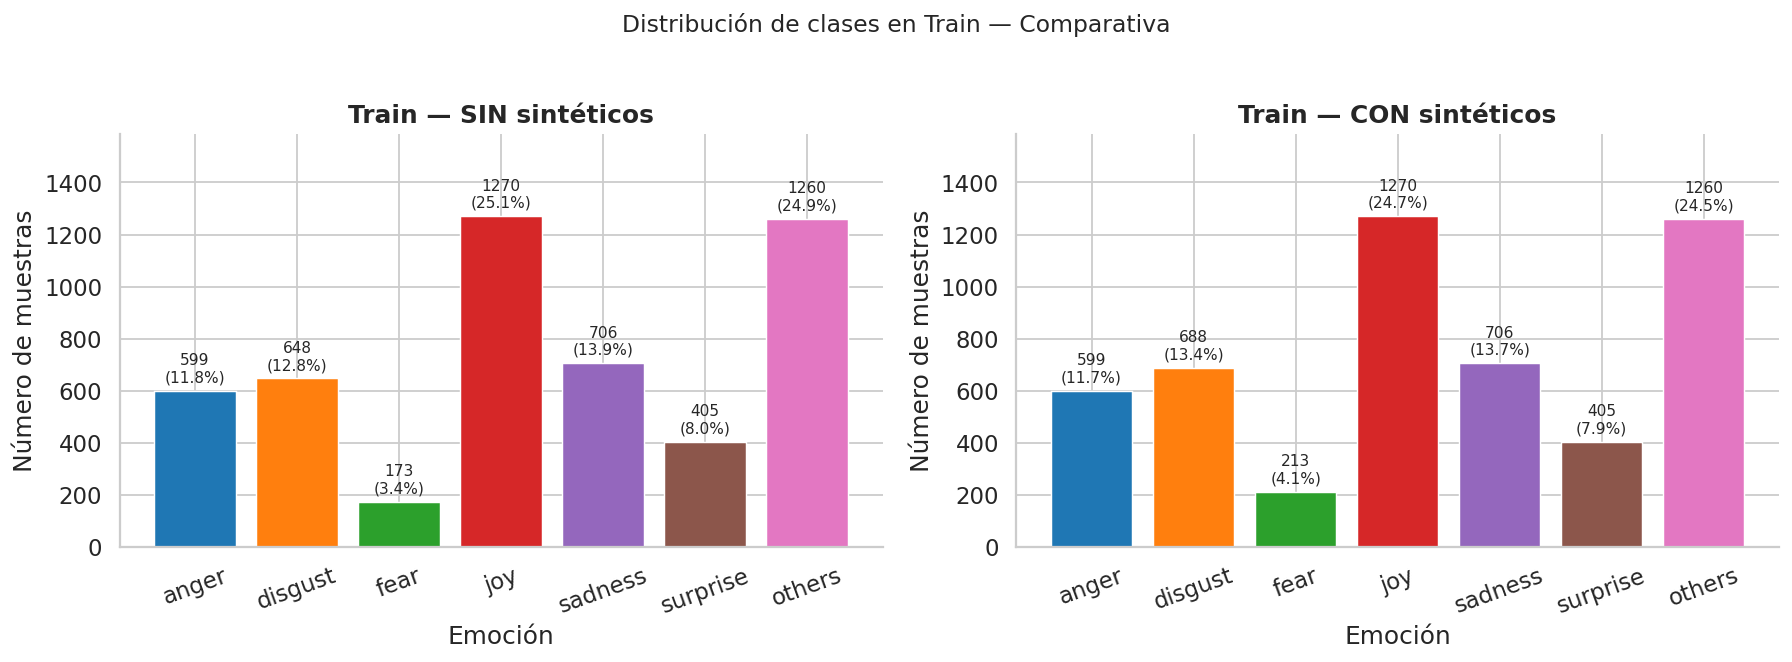

In [8]:
#  Barplot comparativo lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, df, title in zip(axes,
                         [ns_train, ws_train],
                         ['Train — SIN sintéticos', 'Train — CON sintéticos']):
    
    counts = df['emotion'].value_counts().reindex(EMOTION_ORDER, fill_value=0)
    total = counts.sum()
    colors = [EMO_PALETTE[e] for e in EMOTION_ORDER]
    
    bars = ax.bar(EMOTION_ORDER, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    
    # Colocación automática de etiquetas en las barras
    labels = [f'{n}\n({n/total*100:.1f}%)' if n > 0 else '0' for n in counts.values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8.5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Emoción')
    ax.set_ylabel('Número de muestras')
    ax.set_ylim(0, counts.max() * 1.25)
    ax.tick_params(axis='x', rotation=20)
    sns.despine(ax=ax)

plt.suptitle('Distribución de clases en Train — Comparativa', fontsize=13, y=1.02)
plt.tight_layout()
save_custom_plot('train_class_comparison')
plt.show()

In [9]:
# Extracción de métricas puras. Se usa el mínimo de las clases presentes (mayor a 0)
min_ns = ns_train['emotion'].value_counts().min()
min_ws = ws_train['emotion'].value_counts().min()
max_ns = ns_train['emotion'].value_counts().max()
max_ws = ws_train['emotion'].value_counts().max()

ratio_ns = max_ns / min_ns
ratio_ws = max_ws / min_ws
reduction_pct = (1 - ratio_ws/ratio_ns) * 100

print('Métricas Globales de Desequilibrio')
print(f'Ratio Global (Max/Min) SIN sintéticos: {ratio_ns:.2f}x')
print(f'Ratio Global (Max/Min) CON sintéticos: {ratio_ws:.2f}x')
print(f'Reducción matemática del desequilibrio: {reduction_pct:.1f}%')

Métricas Globales de Desequilibrio
Ratio Global (Max/Min) SIN sintéticos: 7.34x
Ratio Global (Max/Min) CON sintéticos: 5.96x
Reducción matemática del desequilibrio: 18.8%


La inyección de datos sintéticos logró reducir el desequilibrio global en un 18.8%, mitigando la brecha de la clase minoritaria crítica (fear) de 7.34x a 5.96x. Verificaremos si las frases sintéticas son válidas para usarlas en el conjunto de entrenamiento. 

## 3. Verificación de Normalización

In [14]:
# 1. Muestreo Cualitativo: Original vs Preprocesado
prep_orig = prep[prep['source'] == 'original'].copy()
raw_es_indexed = raw_es.set_index('id')

sample_ids = prep_orig['id'].sample(10, random_state=42).values

rows = []
for sid in sample_ids:
    raw_text = raw_es_indexed.loc[sid, 'tweet'] if sid in raw_es_indexed.index else '—'
    clean_text = prep_orig.loc[prep_orig['id'] == sid, 'text'].values[0]
    rows.append({'id': sid, 'texto_original': raw_text, 'texto_limpio': clean_text})

df_compare = pd.DataFrame(rows)

print('Muestreo Cualitativo: Ruido de Red Social (Menciones, Enlaces)')
# Usamos Styler para que el texto largo no se trunque y sea fácil de leer
display(df_compare.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

Muestreo Cualitativo: Ruido de Red Social (Menciones, Enlaces)


,id,texto_original,texto_limpio
0,5201,"¡Algo hay que hacer! ¡Orgullosos del nivel de concienciación, salimos a la calle! HASHTAG HASHTAG HASHTAG HASHTAG HASHTAG HASHTAG URL","¡Algo hay que hacer! ¡Orgullosos del nivel de concienciación, salimos a la calle!"
1,2786,"HASHTAG""Amo la soledad de leer,amo zambullirme en la historia de un buen libro,amo el delicioso dolor de la última página"" HASHTAG 📚☕ URL","""Amo la soledad de leer,amo zambullirme en la historia de un buen libro,amo el delicioso dolor de la última página"" libros bebida caliente"
2,88,Pobre incendió en paris en la Catedral de Notre dame HASHTAG a un tiene esperanza,Pobre incendió en paris en la Catedral de Notre dame a un tiene esperanza
3,4781,Oigo llorar a Casado desde mi sofá HASHTAG HASHTAG,Oigo llorar a Casado desde mi sofá
4,3987,"HASHTAG es un iluminado del HASHTAG Lástima que cuando cruza el charco, se le apaga el foquito... HASHTAG HASHTAG","es un iluminado del Lástima que cuando cruza el charco, se le apaga el foquito..."
5,3212,"EN DIRECTO HASHTAG | Barça 0-0 Levante. Los de Valverde dominan, pero no… URL Ver: URL","EN DIRECTO | Barça 0-0 Levante. Los de Valverde dominan, pero no… Ver:"
6,7564,No me lo puedo creer... vergonzoso. HASHTAG URL,No me lo puedo creer... vergonzoso.
7,1644,"Resumen del capítulo de Juegos de Tronos HASHTAG HASHTAG por favor, subidle el brillo URL","Resumen del capítulo de Juegos de Tronos por favor, subidle el brillo"
8,7208,"No puedo más que sentir una enorme pena con HASHTAG. Estamos en una era en la que todo, ya sea queriendo o no, se está perdiendo. Ojalá haya freno para esta espiral... HASHTAG URL","No puedo más que sentir una enorme pena con . Estamos en una era en la que todo, ya sea queriendo o no, se está perdiendo. Ojalá haya freno para esta espiral..."
9,5589,HASHTAG Los bomberos declaran extinguido el incendio de Notre Dame URL URL,Los bomberos declaran extinguido el incendio de Notre Dame


In [16]:
# Verificación Cuantitativa: Purga de Placeholders de Anonimización
tokens_to_check = ['HASHTAG', 'USER', 'URL']

print('Verificación Estricta: Ocurrencias de Placeholders')
for token in tokens_to_check:
    n = prep['text'].str.contains(token, regex=False).sum()
    status = 'OK (0)' if n == 0 else f'ENCONTRADO ({n} filas)'
    print(f'  {token:10s}: {status}')

Verificación Estricta: Ocurrencias de Placeholders
  HASHTAG   : OK (0)
  USER      : OK (0)
  URL       : OK (0)


In [22]:
# Verificación Estructural: Conversión a Texto Descriptivo (Demojize)
EMOJI_PATTERN = re.compile(
    '[\U0001F300-\U0001F9FF\U00002600-\U000027BF\U0001FA00-\U0001FA9F]'
)

raw_es_with_emoji = raw_es[raw_es['tweet'].apply(lambda t: bool(EMOJI_PATTERN.search(str(t))))].copy()
ids_with_emoji = set(raw_es_with_emoji['id'].values)

prep_orig_emoji = prep_orig[prep_orig['id'].isin(ids_with_emoji)]

print('Verificación de Traducción de Emojis=')
print(f'Tweets originales detectados con emoji : {len(raw_es_with_emoji)}')
print(f'Muestras preservadas tras undersampling : {len(prep_orig_emoji)}')
print()

# Muestreo cualitativo de la transformación de emojis
sample_emoji_ids = prep_orig_emoji['id'].sample(min(5, len(prep_orig_emoji)), random_state=112).values
examples = []
for sid in sample_emoji_ids:
    raw_t = raw_es_indexed.loc[sid, 'tweet'] if sid in raw_es_indexed.index else '—'
    clean_t = prep_orig_emoji.loc[prep_orig_emoji['id'] == sid, 'text'].values[0]
    examples.append({'id': sid, 'original_con_emoji': raw_t, 'convertido': clean_t})

display(pd.DataFrame(examples).style.set_properties(**{'text-align': 'left'}))

Verificación de Traducción de Emojis=
Tweets originales detectados con emoji : 1808
Muestras preservadas tras undersampling : 1367



,id,original_con_emoji,convertido
0,7444,"Qué tristeza las fotos del incendio de la catedral de HASHTAG, es una gran pérdida para la humanidad. Así de bella e imponente 👇🏻 URL","Qué tristeza las fotos del incendio de la catedral de , es una gran pérdida para la humanidad. Así de bella e imponente dorso de mano con índice hacia abajo tono de piel claro"
1,5587,Siempre seguirás siendo el hogar de Quasimodo😢😢😢😢 HASHTAG URL,Siempre seguirás siendo el hogar de Quasimodo cara llorando cara llorando cara llorando cara llorando
2,3276,"Gracias a un gol de HASHTAG, el HASHTAG superó al HASHTAG por 1-0 y se proclamó rey de HASHTAG. 🏆 URL","Gracias a un gol de , el superó al por 1-0 y se proclamó rey de . trofeo"
3,3903,No se puede creer más lo de Messi!!! 👏🏽👏🏽👏🏽👏🏽👏🏽 sos ENORME pulga HASHTAG HASHTAG HASHTAG,No se puede creer más lo de Messi!!! manos aplaudiendo tono de piel medio manos aplaudiendo tono de piel medio manos aplaudiendo tono de piel medio manos aplaudiendo tono de piel medio manos aplaudiendo tono de piel medio sos ENORME pulga
4,3247,"⚽️¡BARCELONA BICAMPEÓN! Con un gol de HASHTAG que ingresó en el segundo tiempo, el ""blaugrana"" venció 1-0 a HASHTAG y se coronó en HASHTAG HASHTAG URL vía USER URL","balón de fútbol ¡BARCELONA BICAMPEÓN! Con un gol de que ingresó en el segundo tiempo, el ""blaugrana"" venció 1-0 a y se coronó en vía"


El preprocesamiento eliminó con éxito el 100% de los metadatos residuales (HASHTAG, USER, URL) y transcribió correctamente los emojis a su equivalente textual descriptivo, homogeneizando el corpus sin destruir la señal emocional subyacente.

## 4. Verificación de Traducción (MarianMT)

In [24]:
translated = prep[prep['source'] == 'translated_en'].copy()
raw_en_indexed = raw_en.set_index('id')

print('Muestreo Cruzado: Original (EN) vs Traducción (ES)')

for emotion in ['fear', 'disgust', 'surprise']:
    subset = translated[translated['emotion'] == emotion]
    n_sample = min(15, len(subset))
    
    if n_sample == 0:
        continue
        
    sample = subset.sample(n_sample, random_state=42)
    
    rows = []
    for _, row in sample.iterrows():
        sid = row['id']
        en_text = raw_en_indexed.loc[sid, 'tweet'] if sid in raw_en_indexed.index else '—'
        rows.append({
            'id': int(sid), 
            'inglés_original': en_text, 
            'español_traducido': row['text']
        })
    
    df_pairs = pd.DataFrame(rows)
    print(f'\n[ Emoción: {emotion.upper()}, Muestras: {n_sample} ]')
    
    # Aplicamos estilo para facilitar la lectura de textos largos
    display(df_pairs.style.hide(axis="index") .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'vertical-align': 'top'}))

Muestreo Cruzado: Original (EN) vs Traducción (ES)

[ Emoción: FEAR, Muestras: 15 ]


id,inglés_original,español_traducido
6090,There will come a time when there will be no HASHTAG nights where we are just stunned by the quality of HASHTAG. I’m dreading that day coming.,Llegará un momento en el que no habrá noches en las que sólo estamos aturdidos por la calidad de . Estoy temiendo que el día que viene.
282,"The 2nd leg in two weeks time. If HASHTAG scores a goal, Liverpool has to score 5 goals to win the tie!?? 👀🤔🤭 HASHTAG HASHTAG USER ⚽❤️ URL","La segunda etapa en dos semanas. Si marca un gol, Liverpool tiene que marcar 5 goles para ganar el empate!?? ojos cara pensativa cara con mano sobre la bolsa balan de fútbol corazón rojo"
7242,"Global warming may be occurring more slowly than previously thought, study suggests | The Independent HASHTAG URL","El calentamiento global puede estar ocurriendo más lentamente de lo que se pensaba, el estudio sugiere The Independent"
2361,"'The desire to live fully and experience new things is also felt by many young people with physical, mental and sensory disabilities... they possess amazing resources and abilities that are often far above average' (CV, 149) HASHTAG","""El deseo de vivir plenamente y experimentar cosas nuevas también es sentido por muchos jóvenes con discapacidades físicas, mentales y sensoriales... poseen recursos y habilidades sorprendentes que a menudo están muy por encima de la media"" (CV, 149)"
3733,PLEASE HELP HASHTAG WE NEEDED A HASHTAG URL,POR FAVOR AYUDAMOS A NECESITAMOS UN
2857,"What we know so far about the HASHTAG HASHTAG 1. Smart people said Muslims did it b/c they have been destroying churches around the world2. Looney Left labeled them ALL Alt-Right monsters3. Deemed ""accident"" without investigation so The Crusades don't begin","Lo que sabemos hasta ahora sobre el 1. La gente inteligente dijo que los musulmanes lo hicieron b/c han estado destruyendo iglesias en todo el mundo2. Looney Left les etiqueta a TODOS monstruos Alt-Right3. Considerado ""accidente"" sin investigación por lo que las Cruzadas no comienzan"
5301,"If the coup in Venezuela succeeds, HASHTAG will not become president; Trump will. HASHTAG HASHTAG HASHTAG","Si el golpe en Venezuela tiene éxito, no se convertirá en presidente; Trump lo hará."
2303,An insurrection is underway in HASHTAG. I pray it is successful with minimal bloodshed - it’s too late to expect no bloodshed - and that the Venezuelan people soon find themselves free from the chains shacking them.,Una insurrección está en marcha en . Rezo para que tenga éxito con un derramamiento de sangre mínimo - es demasiado tarde para esperar que no haya derramamiento de sangre - y que el pueblo venezolano pronto se encuentre libre de las cadenas que los acorralan.
6434,"Reason HASHTAG to own an AR-15 (or any other arms)...""A well regulated Militia, being necessary to the security of a free State, the right of the people to keep and bear Arms, shall not be infringed."" 🇺🇸 HASHTAG URL","Razón para poseer un AR-15 (o cualquier otra arma)...""Una Milicia bien regulada, siendo necesaria para la seguridad de un Estado libre, el derecho del pueblo a tener y portar Armas, no será infringido."""
3368,USER In a fight for their lives. HASHTAG 🇻🇪,En una lucha por sus vidas.



[ Emoción: DISGUST, Muestras: 15 ]


id,inglés_original,español_traducido
1861,USER Perhaps her parents & her PR-managers should have considered this first! You can't have a prominent public role & at the same time not expect to also get criticised. Did they pick a teen with Aspergers hoping she would catch less wind? HASHTAG URL,Tal vez sus padres y sus directores de relaciones públicas deberían haber considerado esto primero! No se puede tener un papel público prominente y al mismo tiempo no se espera que también ser criticados. ¿Escogieron a un adolescente con Aspergers con la esperanza de que iba a coger menos viento?
5599,Amazing to me that non-Venezuelans are telling actual Venezuelans that they are wrong about what is going on in their own country. HASHTAG,Sorprendente para mí que los no venezolanos le digan a los venezolanos reales que están equivocados sobre lo que está pasando en su propio país.
6109,This HASHTAG coup is disappointingly non-violent. I've seen more people get crushed in the Central line stairways at Bond Street station,Este golpe es decepcionantemente no violento. He visto a más gente ser aplastada en las escaleras de la línea central en la estación de Bond Street.
7223,Little Marco Rubio tweeted out this could be the last coup attempt there wont be another. I guess Trump is not willing to do a full scale invasion. HASHTAG,El pequeño Marco Rubio tuiteó que este podría ser el último intento de golpe de estado que no habrá otro. Supongo que Trump no está dispuesto a hacer una invasión a gran escala.
2117,Salah misses the easy goal liverpool desperately needed HASHTAG,Salah echa de menos el fácil portero de hígado que se necesita desesperadamente
1034,Fair play from the Dog with a goal celebration against his former club.. HASHTAG HASHTAG,Juego justo del perro con una celebración de goles contra su antiguo club..
6724,Sun Tzu is still turning in his grave because of the stupid battle tactics in that HASHTAG episode both from the defenders and attackers.,"Sun Tzu todavía está girando en su tumba debido a las estúpidas tácticas de batalla en ese episodio, tanto de los defensores como de los atacantes."
4055,"The latest word from the rector re: HASHTAG is that “it could be a computer glitch.” that caused the fire. In other words, “don’t ask us again {because it was arson, stupid.}”","La última palabra del rector re: es que “podría ser un fallo de la computadora.” que causó el fuego. En otras palabras, “no nos pregunte de nuevo {porque fue un incendio provocado, estúpido.}”"
7090,"Between all the giveaways, missed shots on goals and shaky defence, there was HASHTAG, and there was USER, who is a fucking rock. USER USER HASHTAG HASHTAG USER HASHTAG HASHTAG HASHTAG","Entre todos los regalos, tiros perdidos en goles y defensa inestable, había, y había, que es una puta roca."
3665,"I see everyone got the memo from the USER that socialism is bad and always ends in violence. Also tagging their ""boogie woman"". HASHTAG HASHTAG HASHTAG HASHTAG HASHTAG","Veo que todo el mundo tiene el memo de que el socialismo es malo y siempre termina en violencia. También etiquetando a su ""mujer boogie""."



[ Emoción: SURPRISE, Muestras: 15 ]


id,inglés_original,español_traducido
6965,Wow - USER & USER will make for interesting bedfellows... HASHTAG HASHTAG HASHTAG URL,Wow - & hará para los compañeros de cama interesantes...
4437,Just finished USER “Bad Blood” and WOW! It reads like pure make believe. WILD that she got away with so much. Highly recommend! Any other good book reccos?! HASHTAG,Acaba de terminar “Blood Malo” y WOW! Se lee como puro hacer creer. WILD que se salió con la suya tanto. Altamente recomendable! Cualquier otro buen libro Reccos?!
6814,HASHTAG and HASHTAG both in the one night..... I wasn't prepared for such an emotional rollercoaster!,Y ambos en una noche... no estaba preparado para una montaña rusa tan emocional.
2006,HASHTAG Fuck load of use those flaming swords were.,Esas espadas en llamas eran muy útiles.
1057,I feel so empty yet so full inside after watching HASHTAG and HASHTAG ep. 3 😩🥴🥺 what is this feeling!!!!!,Me siento tan vacío pero tan lleno en el interior después de ver y ep. 3 cara agotada cara de grogui cara suplicante lo que es este sentimiento!!!!!
1729,Game of Thrones and Endgame in just over 24 hours... My emotions can't take much more haha HASHTAG HASHTAG,Juego de Tronos y Fin del Juego en poco más de 24 horas... Mis emociones no pueden soportar mucho más jaja
1180,"Edge of the seat stuff, screaming at the TV HASHTAG HASHTAG HASHTAG HASHTAG 😲","Borde de la cosa del asiento, gritando a la cara de la TV asombrada"
4752,USER The only good part of your post is the photo showing the cross and the Pieta still intact and not touched by the fire. HASHTAG,La única buena parte de tu post es la foto que muestra la cruz y la Pieta todavía intacta y no tocada por el fuego.
1222,"Boy, Sean Penn sure is quiet today. HASHTAG","Vaya, Sean Penn está tranquilo hoy."
5119,I truly thought they were all gonna die at one point fuck what an episode HASHTAG,Realmente pensé que todos iban a morir en un momento a la mierda lo que un episodio


La inspección visual confirma que el modelo MarianMT logró transferir de manera efectiva la intensidad emocional, el tono exclamativo y la semántica subyacente de las clases minoritarias del inglés al español.

## 5. Verificación de Datos Sintéticos

In [29]:
# Extracción de muestras sintéticas en el conjunto de entrenamiento
synthetic = ws_train[ws_train['source'] == 'synthetic'].copy()
print('Volumen de Datos Sintéticos en Train')
print(synthetic['emotion'].value_counts().to_string())

Volumen de Datos Sintéticos en Train
emotion
fear       40
disgust    40


In [31]:
# Muestreo Cualitativo (Fear y Disgust)
print('\nMuestreo Cualitativo: Textos Sintéticos (Mistral 7B)')
for emotion in ['fear', 'disgust']:
    sub = synthetic[synthetic['emotion'] == emotion]
    n = min(15, len(sub))
    if n == 0:
        continue
        
    print(f'\n[ Sintéticos: {emotion.upper()}, Muestras: {n} ]')
    display(sub[['id', 'text']].sample(n, random_state=112).reset_index(drop=True).style.hide(axis="index").set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))


Muestreo Cualitativo: Textos Sintéticos (Mistral 7B)

[ Sintéticos: FEAR, Muestras: 15 ]


id,text
nan,30. ¡Que horror! Me han difundido un vídeo comprometedor y ahora todos lo están viendo... no sé cómo enfrentarme a esto.
nan,1. ¡Qué horror... ¿quién se metió en mi perfil y me amenazó? No quiero ser la broma del mes.
nan,"7. ¡Ay, Dios mío! Me han excluido de mi grupo de WhatsApp y ahora me siento totalmente sola."
nan,10. Estoy desesperada... me han robado mi identidad digital y ahora no tengo idea de quién soy yo.
nan,"35. ¿Qué hago si me están tratando de humillar en línea? No puedo más con esta situación, tengo miedo todo el tiempo."
nan,33. ¿Qué hago si me están tratando de intimidar por hablar sobre mi acoso? No puedo estar callada y no tengo nadie que defienda mis derechos.
nan,28. Estoy desesperada... me han creado una cuenta falsa en mi nombre y ahora me están difundiendo cosas comprometedoras.
nan,"25. ¿Qué hago si me están tratando de intimidar en línea? No puedo más con esta situación, tengo miedo todo el tiempo."
nan,"29. ¿Qué hago si me están tratando de humillar por mi apariencia o mis ideologías? No puedo más con esta situación, tengo miedo todo el tiempo."
nan,23. ¿Qué hago si me están tratando de silenciar por hablar sobre mi acoso? No puedo estar callada y no tengo nadie que defienda mis derechos.



[ Sintéticos: DISGUST, Muestras: 15 ]


id,text
nan,"32. ""El ciberacoso es una maldición, por qué nadie me escucha?"""
nan,"6. ""Me han chantajeado con mis fotos y ya no tengo más miedo de ellos. Va a pararse."""
nan,"1. ""Esta mierda de ciberacoso ya me tiene hasta el límite, que no se le da a ese perro sufrido."""
nan,"22. ""El ciberacoso es una mierda horrible, pero no vas a soportarlo mucho tiempo más."""
nan,"17. ""Los amigos te pueden convertir en el blanco de una broma en línea sin saberlo, esa es la verdadera cara del ciberacoso."""
nan,"9. ""El ciberacoso te puede matar la vida, ¿por qué no ponemos fin a esto?"""
nan,"11. ""No importa cuántas veces me amenacen en línea, nunca voy a ceder a sus demandas."""
nan,"23. ""Me han mandado mensajes horribles en WhatsApp y ya no puedo aguantar más."""
nan,"38. ""El ciberacoso es una maldición y ahora me siento completamente perdida."""
nan,"37. ""No importa cuántas veces se te difunden fotos sin tu consentimiento, no dejes que tengas miedo y llames a la policía."""


In [34]:
# Análisis Dimensional (Longitud de textos)
def word_count(text: str) -> int:
    return len(str(text).split())

ws_train['n_words'] = ws_train['text'].apply(word_count)

# Mapeo descriptivo para las leyendas
ws_train['tipo'] = ws_train['source'].map({
    'original': 'Original',
    'translated_en': 'Traducido (EN --> ES)',
    'synthetic': 'Sintético (Ollama)'
})

# Tabla pivote de promedios
mean_table = ws_train.groupby(['emotion', 'tipo'])['n_words'].mean().round(1).unstack()
print('Longitud Media (Palabras) por Emoción y Fuente')
display(mean_table.style.background_gradient(cmap='YlOrRd', axis=None).format(na_rep='-'))

Longitud Media (Palabras) por Emoción y Fuente


tipo,Original,Sintético (Ollama),Traducido (EN --> ES)
emotion,,,
anger,25.900000,-,-
disgust,21.500000,16.600000,26.100000
fear,18.000000,20.000000,25.300000
joy,20.500000,-,-
others,18.700000,-,-
sadness,25.400000,-,-
surprise,18.700000,-,18.700000


Gráfica guardada: length_boxplot_by_source.png


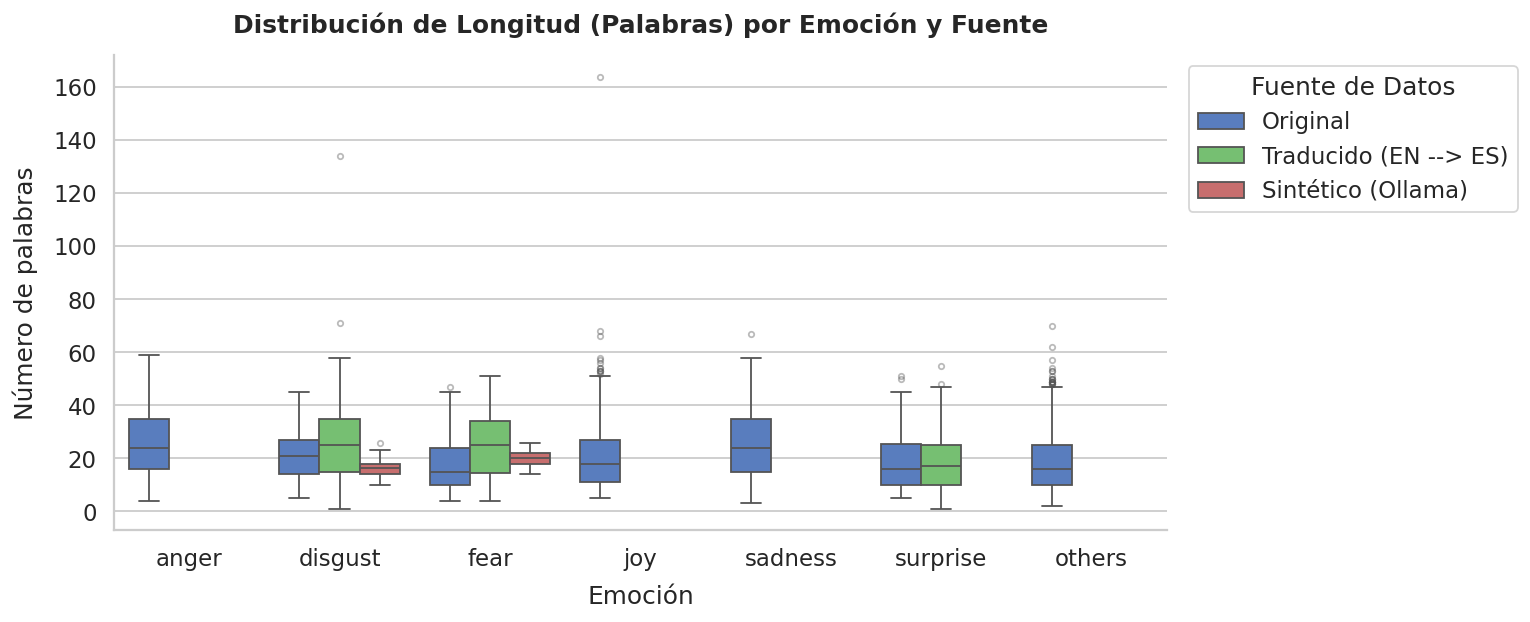

In [38]:
# Boxplot de distribuciones comparadas
order_tipo = ['Original', 'Traducido (EN --> ES)', 'Sintético (Ollama)']
palette_tipo = {'Original': '#4878CF', 'Traducido (EN --> ES)': '#6ACC65', 'Sintético (Ollama)': '#D65F5F'}

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=ws_train[ws_train['tipo'].notna()],
    x='emotion', y='n_words', hue='tipo',
    order=EMOTION_ORDER, hue_order=order_tipo,
    palette=palette_tipo,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('Distribución de Longitud (Palabras) por Emoción y Fuente', fontweight='bold', pad=12)
ax.set_xlabel('Emoción', labelpad=8)
ax.set_ylabel('Número de palabras', labelpad=8)
ax.legend(title='Fuente de Datos', bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine(ax=ax)
plt.tight_layout()

save_custom_plot('length_boxplot_by_source')
plt.show()

**Esta inspección nos da el argumento para descartar los datos sintéticos.** Los textos generados por Mistral caen en un patrón de evidente (repitiendo fórmulas exactas como "¿Qué hago si..." o "El ciberacoso es una maldición..."). Además, el boxplot expone que la varianza de la longitud en los datos sintéticos es casi nula (la caja roja está aplastada) frente a la dispersión asimétrica y natural de los datos humanos y traducidos. Entrenar el clasificador con este corpus sintético provocaría un fuerte sobreajuste (overfitting), haciendo que el modelo aprenda a detectar los patrones, en lugar de entender el lenguaje ruidoso y real del ciberacoso.

## 6. Verificación de Fuga de Datos y Estratificación al corpus que usaremos (Datos Reales + Traducidos)

In [40]:
# Verificación de Fuga de Datos (Data Leakage)
def check_leakage(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame) -> None:
    sets = {
        'Train': set(train['text'].str.strip()),
        'Val':   set(val['text'].str.strip()),
        'Test':  set(test['text'].str.strip()),
    }
    pairs = [('Train', 'Val'), ('Train', 'Test'), ('Val', 'Test')]
    
    print('Intersección de Conjuntos')
    leakage_found = False
    for a, b in pairs:
        overlap = sets[a] & sets[b]
        status = 'OK (0 solapamientos)' if len(overlap) == 0 else f'LEAKAGE: {len(overlap)} textos duplicados'
        print(f'  {a:5s} ∩ {b:5s} : {status}')
        if overlap:
            leakage_found = True
            
    if not leakage_found:
        print('\nESTADO: Particiones estancas. Listo para modelado.')

check_leakage(ns_train, ns_val, ns_test)

Intersección de Conjuntos
  Train ∩ Val   : OK (0 solapamientos)
  Train ∩ Test  : OK (0 solapamientos)
  Val   ∩ Test  : OK (0 solapamientos)

ESTADO: Particiones estancas. Listo para modelado.


In [42]:
# Verificación de Estratificación (Proporción de Clases)
def split_distribution(splits: dict) -> pd.DataFrame:
    rows = {}
    for split_name, df in splits.items():
        counts = df['emotion'].value_counts().reindex(EMOTION_ORDER, fill_value=0)
        rows[split_name] = counts
    return pd.DataFrame(rows)

final_dist = split_distribution({'Train': ns_train, 'Val': ns_val, 'Test': ns_test})

print('Conteos Absolutos por Split')
display(final_dist.style.background_gradient(cmap='Blues', axis=None))

Conteos Absolutos por Split


,Train,Val,Test
emotion,,,
anger,599,128,129
disgust,648,139,139
fear,173,37,37
joy,1270,273,272
sadness,706,151,151
surprise,405,87,87
others,1260,270,270


Gráfica guardada: final_split_stratification_heatmap.png


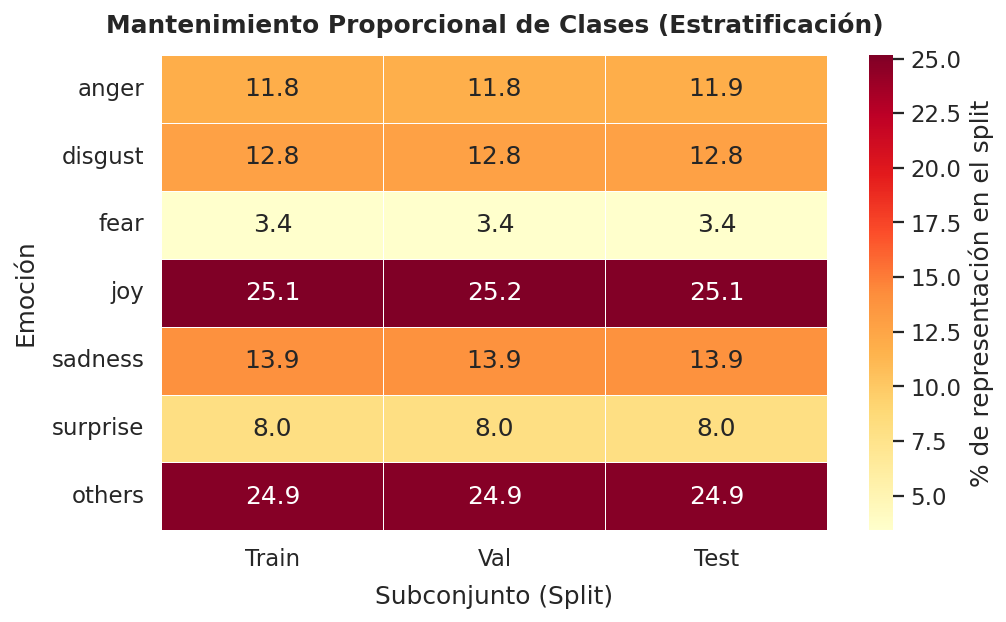

In [43]:
# Heatmap de Mantenimiento Proporcional. Convertimos los conteos absolutos a porcentajes por columna (split)
pct_dist = final_dist.div(final_dist.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pct_dist, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd',
    linewidths=0.5, 
    cbar_kws={'label': '% de representación en el split'},
    ax=ax
)

ax.set_title('Mantenimiento Proporcional de Clases (Estratificación)', fontweight='bold', pad=12)
ax.set_ylabel('Emoción', labelpad=8)
ax.set_xlabel('Subconjunto (Split)', labelpad=8)
plt.tight_layout()

save_custom_plot('final_split_stratification_heatmap')
plt.show()


## 7. Decisión Arquitectónica: Estrategia de Fine-Tuning

Se utilizará exclusivamente el conjunto de datos orgánico (data/processed/no_synthetic/) para la fase de entrenamiento y ajuste fino (fine-tuning) del modelo de clasificación, mitigando el desequilibrio residual mediante ponderación algorítmica (class weights). Esto es debido a los siguientes aspectos:

- **Priorización de la Calidad sobre la Cantidad (Mitigación de Ruido):** El análisis cualitativo reveló que las muestras sintéticas introducen artefactos estructurales severos (fórmulas repetitivas, prefijos anómalos y varianza dimensional nula). La inyección de estos datos degradaría la capacidad de generalización del modelo, provocando un sobreajuste (overfitting) hacia la sintaxis del modelo generador (Mistral) en lugar de capturar la naturaleza asimétrica del ciberacoso real.

- **Abordaje Algorítmico del Desequilibrio:** En lugar de forzar un balanceo a nivel de datos (Data-level), se aplicará una penalización a nivel de algoritmo. Configurar el parámetro class_weight='balanced' en el Trainer ajustará dinámicamente la función de pérdida (Loss), forzando a la red neuronal a penalizar con mayor severidad los errores cometidos en las clases minoritarias (fear, disgust, surprise).

- **Preservación de la Integridad del Corpus:** Al descartar la vía sintética, se garantiza que los subconjuntos de Entrenamiento, Validación y Prueba estén compuestos en un 100% por expresiones semánticas validadas (originales y traducciones humanas cruzadas). Esto asegura que las métricas de evaluación reflejen el rendimiento del modelo en un escenario de producción real.

- **Trazabilidad y Reproducibilidad Científica:** Las particiones que incluyen datos autogenerados (data/processed/with_synthetic/) se conservan en la arquitectura del proyecto como evidencia metodológica empírica de la experimentación fallida con Modelos de Lenguaje Pequeños (SLMs) para tareas de Synthetic Data Generation en dialectos informales.

Si tras la ejecución del fine-tuning las métricas de recuperación y precisión para las clases críticas resultan insuficientes (ej. $\text{F1-Score}_{\text{fear}} < 0.40$), se activarán las siguientes iteraciones:

- **Refinamiento del Prompt Engineering:** Diseñar un marco de generación más restrictivo, aplicando técnicas de Few-Shot Prompting con ejemplos de validación manual, forzando la salida en formato JSON estricto para evitar prefijos conversacionales.

- **Sustitución del Motor Generativo:** Escalar temporalmente la generación de datos desde un modelo local a APIs de modelos LLM que presentan mayor alineamiento en la simulación de dialectos adolescentes.